In [1]:
# 1. Importing Python Modules/Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    RandomForestClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc

In [2]:
# 2. Importing data & Displaying data
df = pd.read_csv("datasets/diabetes.csv")
print(f"Dataset shape: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


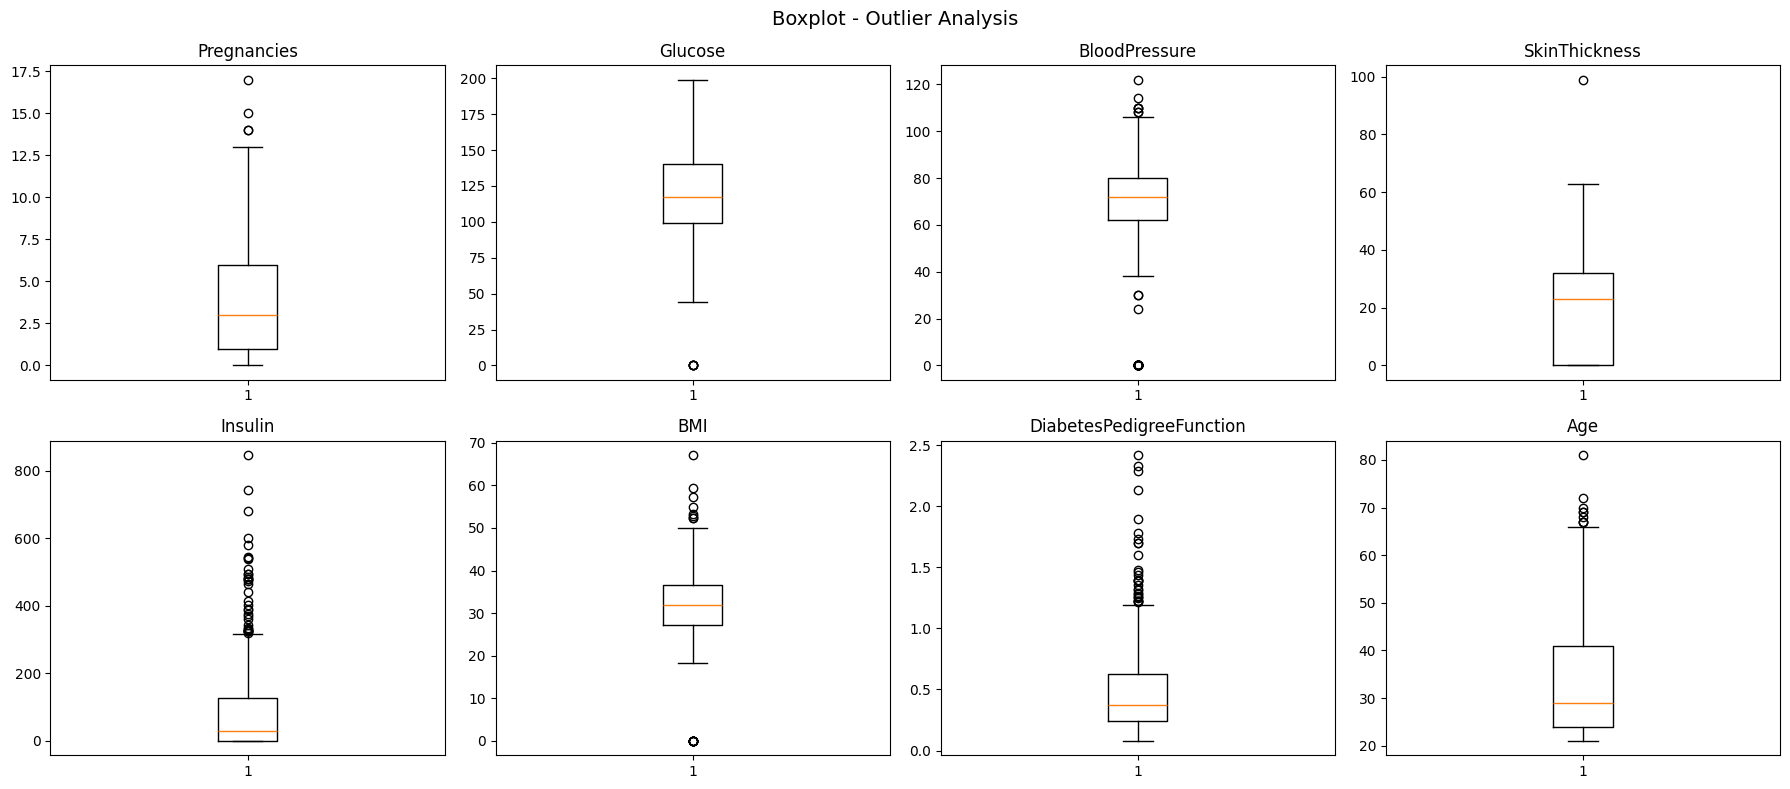


Outlier count (IQR method):
  Pregnancies: 4 outliers
  Glucose: 5 outliers
  BloodPressure: 45 outliers
  SkinThickness: 1 outliers
  Insulin: 34 outliers
  BMI: 19 outliers
  DiabetesPedigreeFunction: 29 outliers
  Age: 9 outliers


In [3]:
# 3. Statistical Analysis & Outlier Analysis
print("Statistical Summary:")
display(df.describe())

# Outlier analysis using boxplots
numeric_cols = df.select_dtypes(include=np.number).columns.drop("Outcome")
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
plt.suptitle("Boxplot - Outlier Analysis", fontsize=14)
plt.tight_layout()
plt.show()

# Detecting outliers using IQR method
print("\nOutlier count (IQR method):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers")

In [4]:
# 4. Creating the Independent and Dependent variables
X = df.drop("Outcome", axis=1)  # Features
y = df["Outcome"]               # Target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features (X) shape: (768, 8)
Target (y) shape: (768,)
Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [5]:
# 5. Replacing missing values with meaningful value
# In the diabetes dataset, 0 values in certain columns are biologically impossible
# and represent missing data (Glucose, BloodPressure, SkinThickness, Insulin, BMI)
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero counts before imputation:")
for col in zero_cols:
    print(f"  {col}: {(X[col] == 0).sum()}")

X[zero_cols] = X[zero_cols].replace(0, np.nan)
X[zero_cols] = X[zero_cols].fillna(X[zero_cols].mean())

print("\nZero counts after imputation:")
for col in zero_cols:
    print(f"  {col}: {(X[col] == 0).sum()}")

print("\nMissing values after imputation:")
print(X.isnull().sum())

Zero counts before imputation:
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11

Zero counts after imputation:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [6]:
# 6. Splitting the data into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("Feature scaling complete.")

Training set size: 614
Test set size: 154
Feature scaling complete.


Bagging Classifier Results:
Accuracy: 0.7597

              precision    recall  f1-score   support

 No Diabetes       0.82      0.81      0.81        99
    Diabetes       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



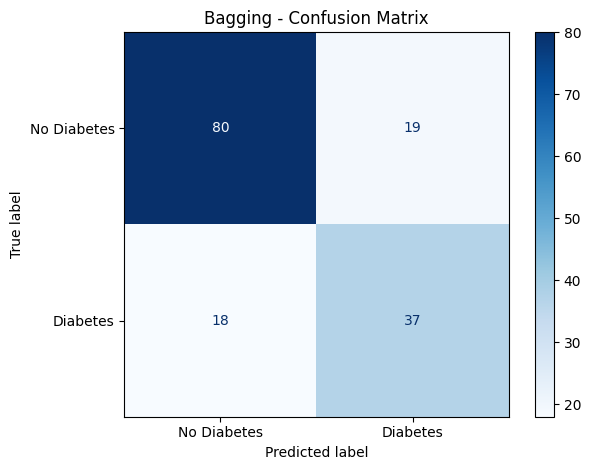

AdaBoost Classifier Results:
Accuracy: 0.7857

              precision    recall  f1-score   support

 No Diabetes       0.84      0.83      0.83        99
    Diabetes       0.70      0.71      0.70        55

    accuracy                           0.79       154
   macro avg       0.77      0.77      0.77       154
weighted avg       0.79      0.79      0.79       154



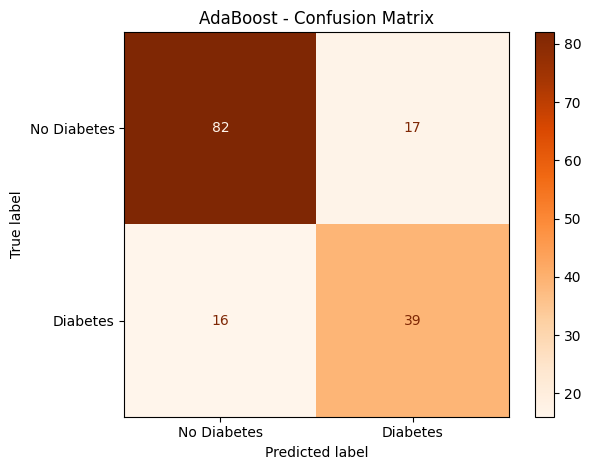

Gradient Boosting Classifier Results:
Accuracy: 0.7338

              precision    recall  f1-score   support

 No Diabetes       0.82      0.76      0.79        99
    Diabetes       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



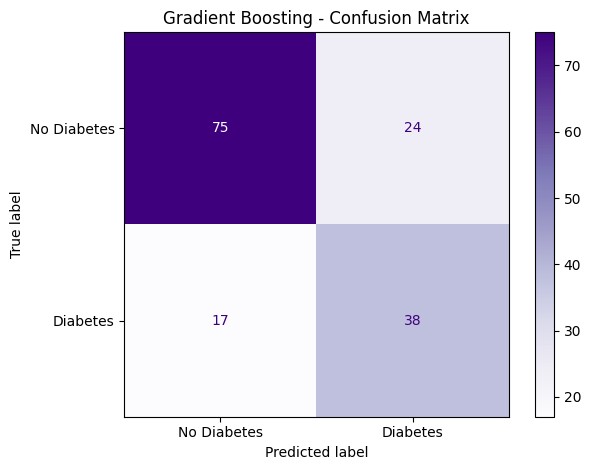

Voting Classifier (Soft) Results:
Accuracy: 0.7662

              precision    recall  f1-score   support

 No Diabetes       0.81      0.83      0.82        99
    Diabetes       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



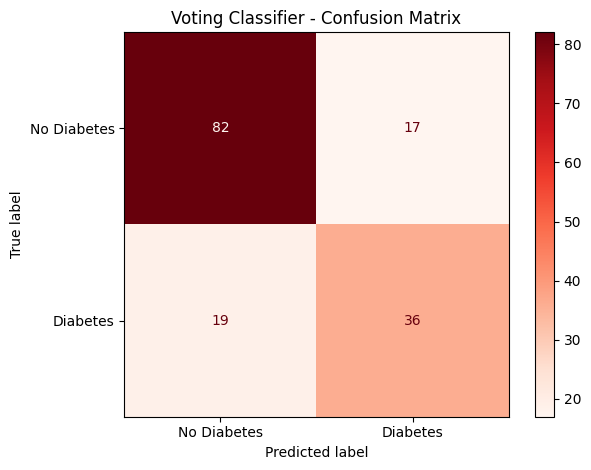


Ensemble Learning - Comparison
       Classifier  Accuracy
         AdaBoost  0.785714
    Voting (Soft)  0.766234
          Bagging  0.759740
Gradient Boosting  0.733766


In [7]:
# 7. Apply Ensemble Learning and check its performance

# --- Bagging Classifier ---
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50, random_state=42
)
bagging_clf.fit(X_train_scaled, y_train)
y_pred_bag = bagging_clf.predict(X_test_scaled)
bag_acc = accuracy_score(y_test, y_pred_bag)

print("=" * 50)
print("Bagging Classifier Results:")
print("=" * 50)
print(f"Accuracy: {bag_acc:.4f}\n")
print(classification_report(y_test, y_pred_bag, target_names=["No Diabetes", "Diabetes"]))

cm_bag = confusion_matrix(y_test, y_pred_bag)
ConfusionMatrixDisplay(confusion_matrix=cm_bag, display_labels=["No Diabetes", "Diabetes"]).plot(cmap='Blues')
plt.title("Bagging - Confusion Matrix")
plt.tight_layout()
plt.show()

# --- AdaBoost Classifier ---
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, learning_rate=0.5, random_state=42
)
ada_clf.fit(X_train_scaled, y_train)
y_pred_ada = ada_clf.predict(X_test_scaled)
ada_acc = accuracy_score(y_test, y_pred_ada)

print("=" * 50)
print("AdaBoost Classifier Results:")
print("=" * 50)
print(f"Accuracy: {ada_acc:.4f}\n")
print(classification_report(y_test, y_pred_ada, target_names=["No Diabetes", "Diabetes"]))

cm_ada = confusion_matrix(y_test, y_pred_ada)
ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=["No Diabetes", "Diabetes"]).plot(cmap='Oranges')
plt.title("AdaBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

# --- Gradient Boosting Classifier ---
gb_clf = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
)
gb_clf.fit(X_train_scaled, y_train)
y_pred_gb = gb_clf.predict(X_test_scaled)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("=" * 50)
print("Gradient Boosting Classifier Results:")
print("=" * 50)
print(f"Accuracy: {gb_acc:.4f}\n")
print(classification_report(y_test, y_pred_gb, target_names=["No Diabetes", "Diabetes"]))

cm_gb = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=["No Diabetes", "Diabetes"]).plot(cmap='Purples')
plt.title("Gradient Boosting - Confusion Matrix")
plt.tight_layout()
plt.show()

# --- Voting Classifier (Hard Voting) ---
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
    ],
    voting='soft'
)
voting_clf.fit(X_train_scaled, y_train)
y_pred_vote = voting_clf.predict(X_test_scaled)
vote_acc = accuracy_score(y_test, y_pred_vote)

print("=" * 50)
print("Voting Classifier (Soft) Results:")
print("=" * 50)
print(f"Accuracy: {vote_acc:.4f}\n")
print(classification_report(y_test, y_pred_vote, target_names=["No Diabetes", "Diabetes"]))

cm_vote = confusion_matrix(y_test, y_pred_vote)
ConfusionMatrixDisplay(confusion_matrix=cm_vote, display_labels=["No Diabetes", "Diabetes"]).plot(cmap='Reds')
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# --- Ensemble Comparison ---
print("\n" + "=" * 50)
print("Ensemble Learning - Comparison")
print("=" * 50)
ensemble_comparison = pd.DataFrame({
    "Classifier": ["Bagging", "AdaBoost", "Gradient Boosting", "Voting (Soft)"],
    "Accuracy": [bag_acc, ada_acc, gb_acc, vote_acc]
}).sort_values(by="Accuracy", ascending=False)
print(ensemble_comparison.to_string(index=False))

Random Forest Classifier Results:
Accuracy: 0.7597

              precision    recall  f1-score   support

 No Diabetes       0.80      0.84      0.82        99
    Diabetes       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



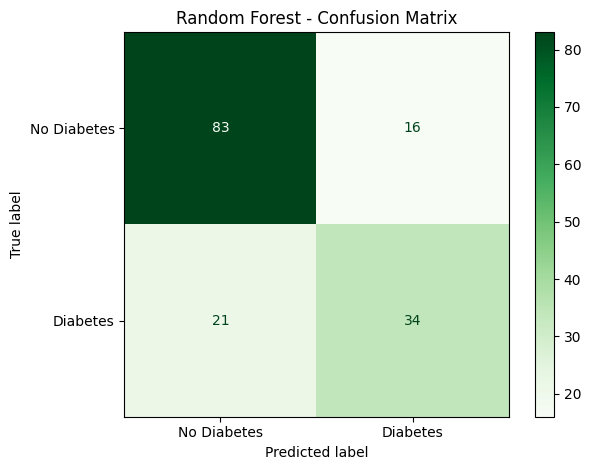

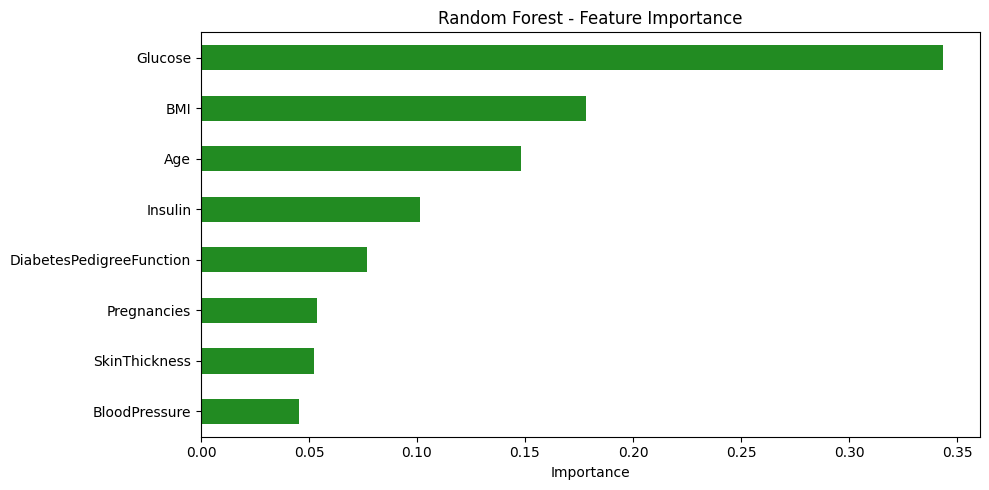

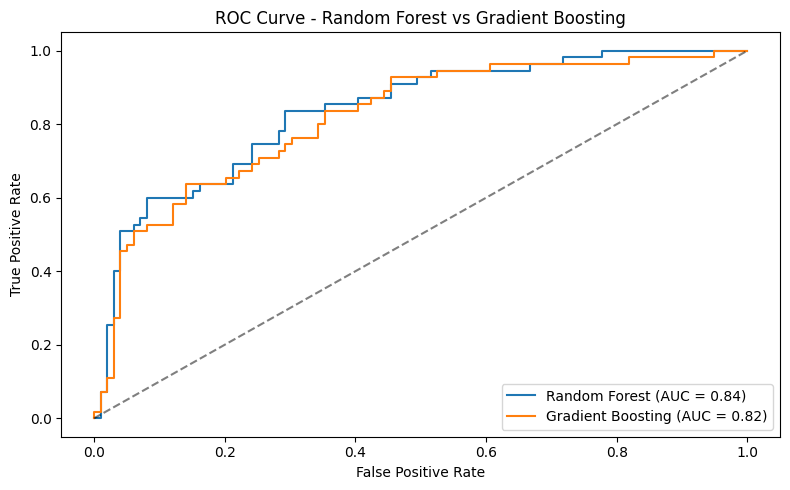


Final Comparison: All Classifiers
       Classifier  Accuracy
         AdaBoost  0.785714
    Voting (Soft)  0.766234
          Bagging  0.759740
    Random Forest  0.759740
Gradient Boosting  0.733766

Best classifier: AdaBoost (0.7857)


In [8]:
# 8. Apply Random Forest and check its performance
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("=" * 50)
print("Random Forest Classifier Results:")
print("=" * 50)
print(f"Accuracy: {rf_acc:.4f}\n")
print(classification_report(y_test, y_pred_rf, target_names=["No Diabetes", "Diabetes"]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Diabetes", "Diabetes"]).plot(cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature Importance
feature_imp = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True)
feature_imp.plot(kind='barh', figsize=(10, 5), color='forestgreen')
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ROC Curve - Random Forest vs Best Ensemble
y_prob_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]
y_prob_gb = gb_clf.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest vs Gradient Boosting")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Final Overall Comparison
print("\n" + "=" * 50)
print("Final Comparison: All Classifiers")
print("=" * 50)
final_comparison = pd.DataFrame({
    "Classifier": ["Bagging", "AdaBoost", "Gradient Boosting", "Voting (Soft)", "Random Forest"],
    "Accuracy": [bag_acc, ada_acc, gb_acc, vote_acc, rf_acc]
}).sort_values(by="Accuracy", ascending=False)
print(final_comparison.to_string(index=False))
print(f"\nBest classifier: {final_comparison.iloc[0]['Classifier']} ({final_comparison.iloc[0]['Accuracy']:.4f})")